Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


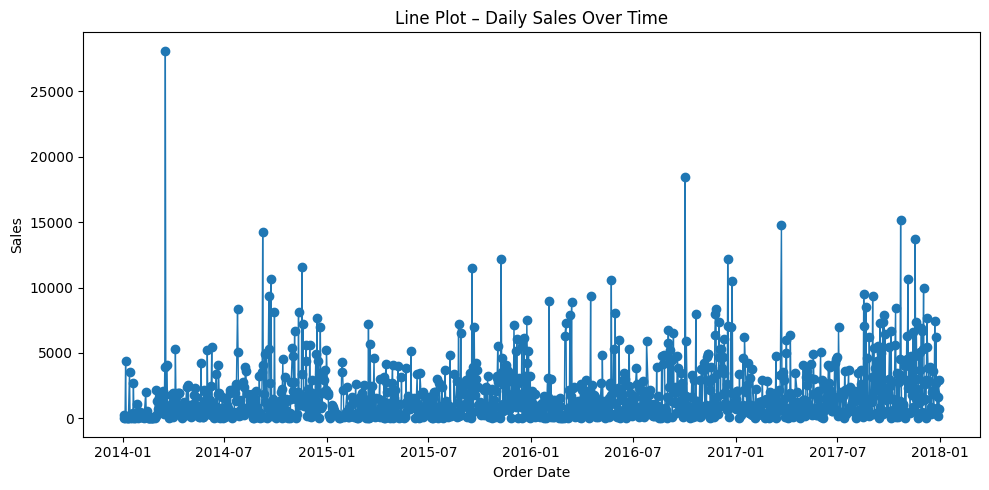

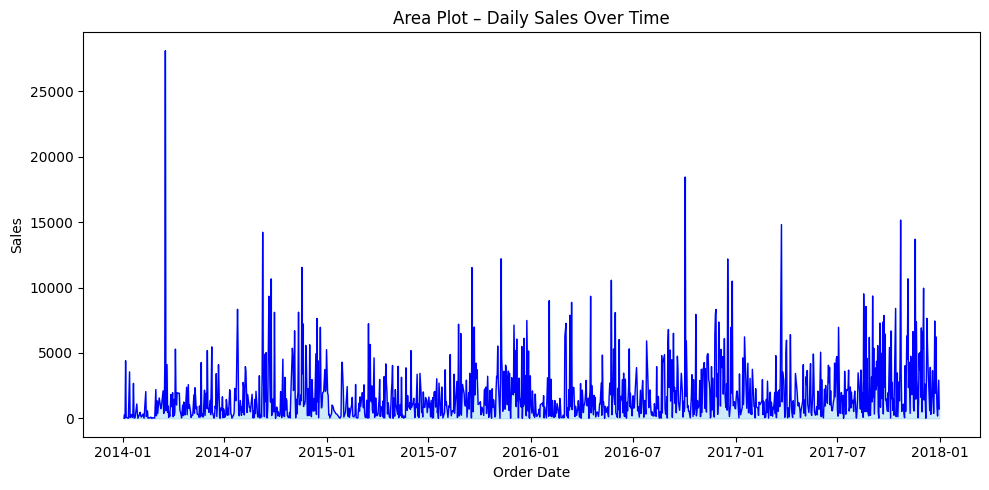

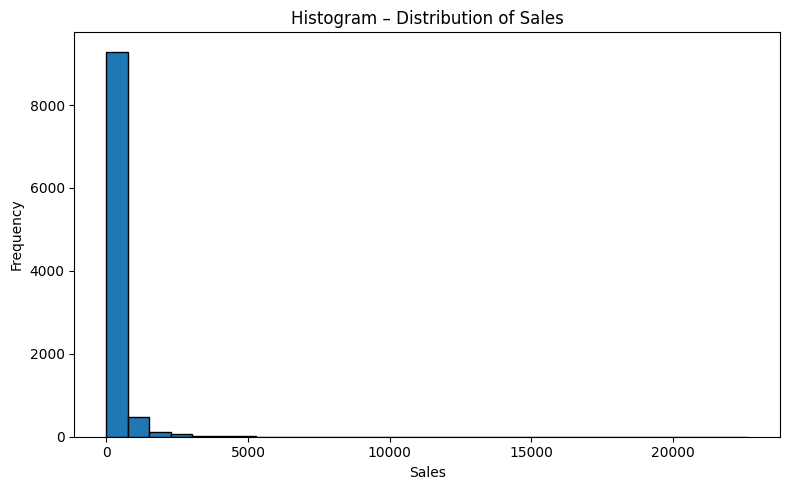

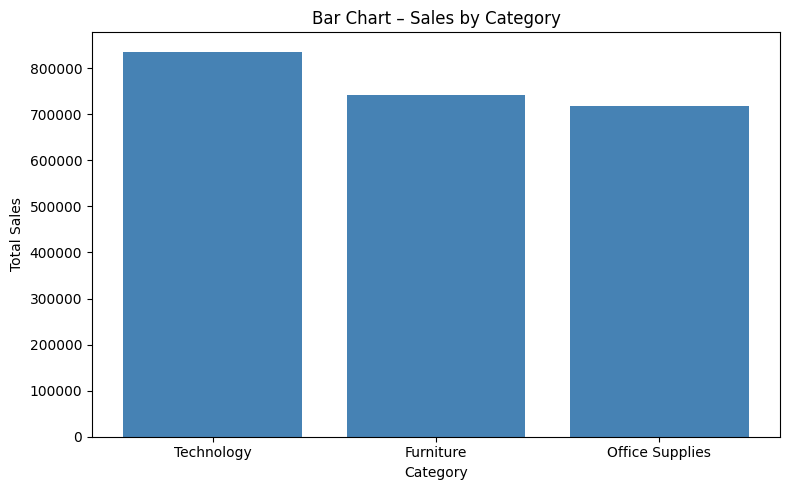

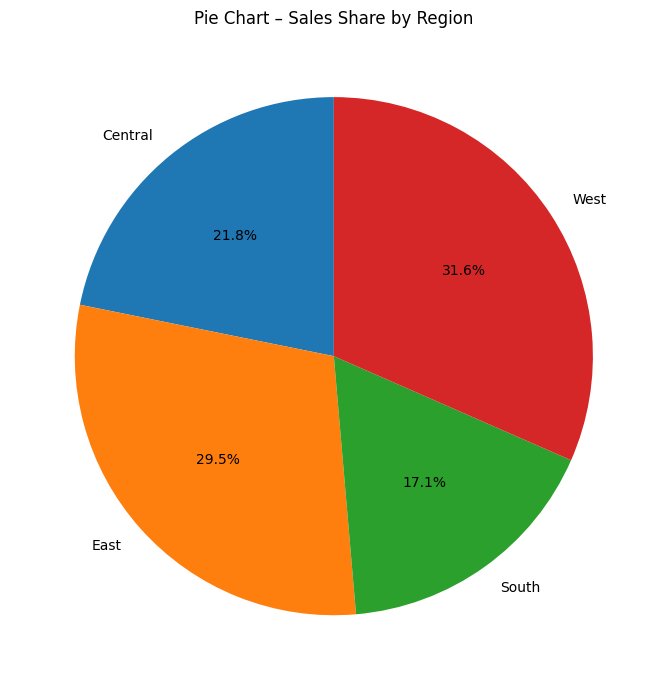

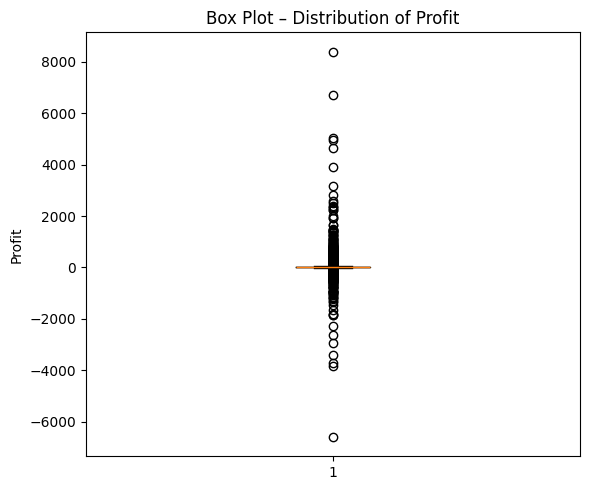

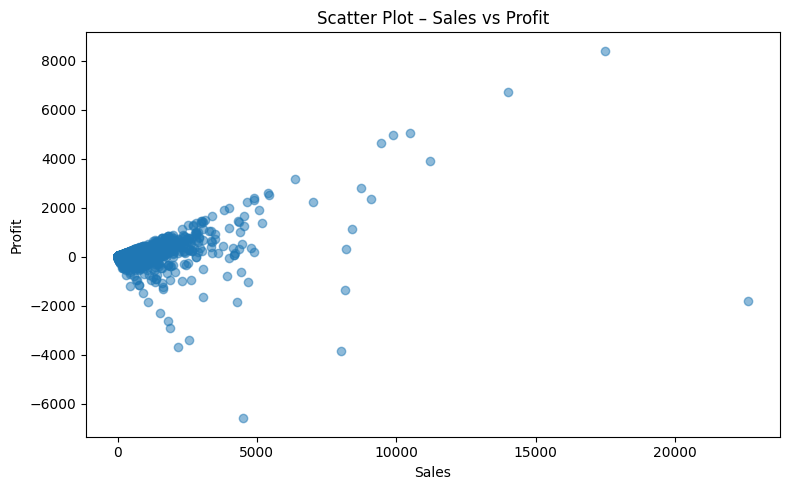

In [1]:
# Assignment 1: Basic Data Visualization Plots
# Dataset: Superstore sales dataset from Kaggle (superstore-dataset-final) [web:57]

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset (update path if needed)
# Example: keep Superstore dataset CSV in same folder and rename to "superstore.csv"
df = pd.read_csv("superstore.csv", encoding="latin1")

# Optional: check columns
print(df.columns)

# Convert Order Date to datetime if present
if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])

# ---------- LINE PLOT: Sales over time ----------
# Use daily sales; you can also resample to month if you like
if 'Order Date' in df.columns and 'Sales' in df.columns:
    sales_by_date = df.groupby('Order Date')['Sales'].sum().sort_index()

    plt.figure(figsize=(10, 5))
    plt.plot(sales_by_date.index, sales_by_date.values, marker='o', linewidth=1)
    plt.title("Line Plot – Daily Sales Over Time")
    plt.xlabel("Order Date")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()

# ---------- AREA PLOT: Sales over time ----------
if 'Order Date' in df.columns and 'Sales' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.fill_between(sales_by_date.index, sales_by_date.values, alpha=0.4, color='skyblue')
    plt.plot(sales_by_date.index, sales_by_date.values, color='blue', linewidth=1)
    plt.title("Area Plot – Daily Sales Over Time")
    plt.xlabel("Order Date")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()

# ---------- HISTOGRAM: Distribution of Sales ----------
if 'Sales' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df['Sales'], bins=30, edgecolor='black')
    plt.title("Histogram – Distribution of Sales")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# ---------- BAR CHART: Sales by Category ----------
if 'Category' in df.columns and 'Sales' in df.columns:
    sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    plt.bar(sales_by_cat.index, sales_by_cat.values, color='steelblue')
    plt.title("Bar Chart – Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Total Sales")
    plt.tight_layout()
    plt.show()

# ---------- PIE CHART: Sales share by Region ----------
# You can change Region to Category if Region not present
col_for_pie = 'Region' if 'Region' in df.columns else 'Category'
sales_by_region = df.groupby(col_for_pie)['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    sales_by_region.values,
    labels=sales_by_region.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title(f"Pie Chart – Sales Share by {col_for_pie}")
plt.tight_layout()
plt.show()

# ---------- BOX PLOT: Profit distribution ----------
# Use Profit if available, else Sales
value_col = 'Profit' if 'Profit' in df.columns else 'Sales'

plt.figure(figsize=(6, 5))
plt.boxplot(df[value_col].dropna(), vert=True)
plt.title(f"Box Plot – Distribution of {value_col}")
plt.ylabel(value_col)
plt.tight_layout()
plt.show()

# ---------- SCATTER PLOT: Sales vs Profit ----------
if 'Sales' in df.columns and 'Profit' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
    plt.title("Scatter Plot – Sales vs Profit")
    plt.xlabel("Sales")
    plt.ylabel("Profit")
    plt.tight_layout()
    plt.show()
